In [68]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torch.optim as optim
from sklearn.model_selection import train_test_split 
import numpy as np

import matplotlib.pyplot as plt

import statistics 



In [54]:
DEVICE  = torch.device(f"cuda:0" if torch.cuda.is_available() else "cpu")
print(DEVICE)


cuda:0


In [61]:
def plot_class_distribution(class_percentage):
    """
    Plot the class distribution as a bar chart.
    
    Parameters:
    - class_percentage: dictionary with class IDs as keys and their respective percentage of pixels.
    """
    classes = list(class_percentage.keys())
    percentages = list(class_percentage.values())
    
    plt.bar(classes, percentages, color='b', alpha=0.7)
    plt.xlabel('Class ID')
    plt.ylabel('Percentage of Pixels (%)')
    plt.title('Class Distribution Across Dataset')
    plt.xticks(classes)  # Ensure all class IDs are labeled on the x-axis
    plt.show()
    
def calculate_overall_class_distribution(labels_dataset, include_no_data=True, show_plot=True):
    """
    Calculate the overall class distribution across all patches in the dataset.
    
    Parameters:
    - labels_dataset: numpy array of shape (num_patches, 64, 64) representing the patches.
    
    Returns:
    - overall_class_percentage: dictionary with the class ID as key and percentage of pixels across all patches.
    """
    if include_no_data:
        overall_class_counts = {i: 0 for i in (set(range(-1, 10))-{0})} # Assuming 10 classes
    else:
        overall_class_counts = {i: 0 for i in range(1, 10)}
    total_pixels = 0

    # Loop through all patches in the dataset
    for labels_patch in labels_dataset:
        flattened_patch = labels_patch.flatten()
        total_pixels += flattened_patch.size
        
        # Count class pixels in the current patch
        class_counts = {i: np.sum(flattened_patch == i) for i in overall_class_counts.keys()}

        for cls, count in class_counts.items():
            overall_class_counts[cls] += count

    # Calculate the percentage for each class across all patches
    overall_class_percentage = {cls: (count / total_pixels) * 100 for cls, count in overall_class_counts.items()}   

    if show_plot:
        plot_class_distribution(overall_class_percentage)
    
    return overall_class_percentage


class PatchEmbedding(nn.Module):
    def __init__(self, in_channels, patch_size, emb_dim, img_size):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, emb_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)  # (B, emb_dim, H/patch, W/patch)
        x = x.flatten(2)  # (B, emb_dim, num_patches)
        x = x.transpose(1, 2)  # (B, num_patches, emb_dim)
        return x


# Basic Transformer Block
class TransformerBlock(nn.Module):
    def __init__(self, emb_dim, heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(emb_dim)
        self.attn = nn.MultiheadAttention(emb_dim, heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(emb_dim)
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, emb_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x = x + attn_out  # Residual
        x_norm = self.norm2(x)
        x = x + self.mlp(x_norm)  # Residual
        return x


class Discriminator():
    def __init__(self, img_size=64, patch_size=8, in_channels=4, emb_dim=256, depth=6, heads=4, mlp_dim=512):
        super().__init__()
        self.patch_embed = PatchEmbedding(in_channels, patch_size, emb_dim, img_size)
        self.cls_token = nn.Parameter(torch.randn(1, 1, emb_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, (img_size // patch_size) ** 2 + 1, emb_dim))
        self.transformer = nn.Sequential(
            *[TransformerBlock(emb_dim, heads, mlp_dim) for _ in range(depth)]
        )
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(emb_dim),
            nn.Linear(emb_dim, 1),
        )

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)  # (B, N, D)
        cls_tokens = self.cls_token.expand(B, -1, -1)  # (B, 1, D)
        x = torch.cat((cls_tokens, x), dim=1)  # prepend CLS token
        x = x + self.pos_embed  # Add positional encoding
        x = self.transformer(x)
        cls_out = x[:, 0]  # Only the CLS token
        return self.mlp_head(cls_out)  # Real/fake score

          

class Generator():
    def __init__(self, noise_dim=100, img_size=64, patch_size=8, out_channels=4, emb_dim=256, depth=6, heads=4, mlp_dim=512):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.linear_proj = nn.Linear(noise_dim, self.num_patches * emb_dim)
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, emb_dim))
        self.transformer = nn.Sequential(
            *[TransformerBlock(emb_dim, heads, mlp_dim) for _ in range(depth)]
        )
        self.output_proj = nn.Sequential(
            nn.Linear(emb_dim, patch_size * patch_size * out_channels),
        )
        self.patch_size = patch_size
        self.out_channels = out_channels
        self.img_size = img_size

    def forward(self, z):
        B = z.size(0)
        x = self.linear_proj(z)  # (B, num_patches * D)
        x = x.view(B, self.num_patches, -1)  # (B, num_patches, D)
        x = x + self.pos_embed
        x = self.transformer(x)
        x = self.output_proj(x)  # (B, num_patches, patch_dim)

        # Reconstruct image from patches
        x = x.view(B, self.img_size // self.patch_size, self.img_size // self.patch_size, 
                   self.patch_size, self.patch_size, self.out_channels)
        x = x.permute(0, 5, 1, 3, 2, 4).contiguous()
        x = x.view(B, self.out_channels, self.img_size, self.img_size)
        return torch.tanh(x)  # Output in [-1, 1]

In [74]:
#Load dataset
# agumented_data = np.load(r'../Dataset/s2-utm-33N-18E-242N-2018/7_augumented_data_64X64_majority60.npy') 
# agumented_labels = np.load(r'../Dataset/s2-utm-33N-18E-242N-2018/8_augumented_labels_64X64_majority60.npy') 

# original_data = np.load(r"../Dataset/s2-utm-33N-18E-242N-2018/9_filtered_data_64X64_majority60.npy")
# original_labels = np.load(r"../Dataset/s2-utm-33N-18E-242N-2018/10_filtered_labels_64X64_majority60.npy")

data = np.load(r'../Dataset/s2-utm-33N-18E-242N-2018/DS2/11_final_gan_data_without_mixed_patches_64X64_majority60.npy')
labels = np.load(r'../Dataset/s2-utm-33N-18E-242N-2018/DS2/12_final_gan_labels_without_mixed_patches_64X64_majority60.npy')

print(data.shape)
print(labels.shape)



(4403, 64, 64, 4)
(4403, 64, 64)


In [75]:
min_varience = None
index = None
extreme_diffs = None
extreme_diff_index = None
for i in range(1,1000):
    train_data, validation_test_data, train_labels, validation_test_labels = train_test_split(data, labels, test_size=0.2, random_state=i)
    validation_data, test_data, validation_labels, test_labels = train_test_split(data, labels, test_size=0.2, random_state=2)

    dict_percs = calculate_overall_class_distribution(train_labels, include_no_data= False, show_plot=False)
    values = dict_percs.values()

    std = statistics.variance(values)


    if i%100==0:
        print(i)

    if min_std == None:
        min_std = std
        index = i
    elif std<min_std:
        min_std = std
        index = i

    max_min_diff = max(values)- min(values)
    if extreme_diffs == None:
        extreme_diffs = max_min_diff
        extreme_diff_index = i
    elif max_min_diff<extreme_diffs:
        extreme_diffs = max_min_diff
        extreme_diff_index = i

print(index, min_std) 
print(extreme_diff_index, extreme_diffs)


100
200
300
400
500
600
700
800
900
68 0.5551890000102045
636 1.9590378890722597


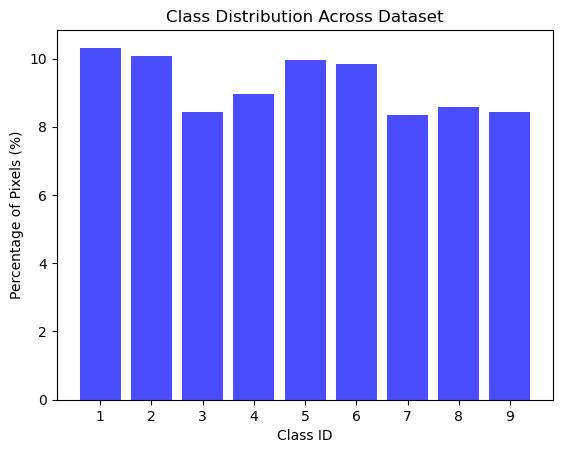

{1: 10.316688238660563,
 2: 10.071022601238642,
 3: 8.429852755891538,
 4: 8.953264746592845,
 5: 9.957866679532227,
 6: 9.82702754560619,
 7: 8.357650349588303,
 8: 8.580856713160136,
 9: 8.429714118398637}

In [79]:
train_data, validation_test_data, train_labels, validation_test_labels = train_test_split(data, labels, test_size=0.2, random_state=636)
validation_data, test_data, validation_labels, test_labels = train_test_split(data, labels, test_size=0.2, random_state=913)

calculate_overall_class_distribution(train_labels, include_no_data= False)


In [ ]:
class Generator(nn.Module):
    def __init__(self, noise_dim, label_dim):
        super(Generator, self).__init__()
        self.fc = nn.Linear(noise_dim + label_dim, 512 * 4 * 4)

        self.net = nn.Sequential(
            nn.BatchNorm2d(512),
            nn.ReLU(),

            nn.ConvTranspose2d(512, 256, 4, 2, 1),  # 8x8
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 16x16
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 32x32
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 4, 4, 2, 1),     # 64x64x4
        )

    def forward(self, z, labels):
        labels = labels.view(labels.size(0), -1)  # flatten 64x64 -> 4096
        x = torch.cat([z, labels], dim=1)
        x = self.fc(x).view(x.size(0), 512, 4, 4)
        return self.net(x)


In [ ]:
import torch
import torch.nn as nn

class Discriminator(nn.Module):
    def __init__(self, num_classes=9):
        super(Discriminator, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(4, 64, 4, 2, 1),  # 32x32
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),  # 16x16
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),  # 8x8
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 512, 4, 2, 1),  # 4x4
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
        )

        self.adv_head = nn.Conv2d(512, 1, 4)  # real/fake output, shape: [B,1,1,1]

        self.seg_head = nn.Sequential(
            nn.ConvTranspose2d(512, 128, 4, 2, 1),  # 8x8
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),    # 32x32
            nn.ReLU(),
            nn.ConvTranspose2d(32, num_classes, 4, 2, 1),  # 64x64 output logits (no activation)
        )

    def forward(self, x):
        features = self.encoder(x)
        real_fake = self.adv_head(features).view(-1)  # flatten to [B]
        class_map = self.seg_head(features)  # shape [B, num_classes, 64, 64]
        return real_fake, class_map


In [ ]:
class ImageLabelDataset(Dataset):
    def __init__(self, image_array, label_array):
        self.images = torch.tensor(image_array, dtype=torch.float32)  # (N, 4, 64, 64)
        self.labels = torch.tensor(label_array, dtype=torch.float32)  # (N, 1, 64, 64)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


In [ ]:
# Optimizers and loss
adversarial_loss = nn.BCEWithLogitsLoss()
auxiliary_loss = nn.CrossEntropyLoss()
bce_loss = nn.BCELoss()
noise_dim = 100

G = Generator(noise_dim, 64*64).to(DEVICE)
D = Discriminator().to(DEVICE)

g_optimizer = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_optimizer = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

bce_loss = nn.BCELoss()
noise_dim = 100

G = Generator(noise_dim, 64*64).to(DEVICE)
D = Discriminator().to(DEVICE)

g_optimizer = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_optimizer = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

def train_acgan(dataloader, epochs=10):
    for epoch in range(epochs):
        for real_imgs, real_labels in dataloader:
            real_imgs = real_imgs.to(DEVICE)
            real_labels = real_labels.to(DEVICE)

            batch_size = real_imgs.size(0)
            # valid = torch.ones(batch_size, device=DEVICE)
            # fake = torch.zeros(batch_size, device=DEVICE)

            # ---------------------
            #  Train Discriminator
            # ---------------------
            d_optimizer.zero_grad()

            # Real loss
            real_pred, real_seg = D(real_imgs)

            # Hinge loss for real images
            d_real_loss_adv = torch.relu(1.0 - real_pred).mean()

            # Auxiliary segmentation loss (use CrossEntropy)
            d_real_loss_aux = auxiliary_loss(real_seg, real_labels)

            # Fake loss
            z = torch.randn(batch_size, noise_dim, device=DEVICE)
            fake_imgs = G(z, real_labels)
            fake_pred, fake_seg = D(fake_imgs.detach())
            # Hinge loss for fake images
            d_fake_loss_adv = torch.relu(1.0 + fake_pred).mean()
            # Auxiliary loss for fake images
            d_fake_loss_aux = auxiliary_loss(fake_seg, real_labels)

            d_loss = d_real_loss_adv + d_fake_loss_adv + d_real_loss_aux + d_fake_loss_aux
            d_loss.backward()
            d_optimizer.step()

            # -----------------
            #  Train Generator
            # -----------------
            g_optimizer.zero_grad()

            gen_pred, gen_seg = D(fake_imgs)

            # Generator adversarial hinge loss (maximize D(fake))
            g_adv_loss = -gen_pred.mean()

             # Generator auxiliary loss: want D to predict correct classes for fake imgs
            g_aux_loss = auxiliary_loss(gen_seg, real_labels)
            
            g_loss =g_adv_loss+g_aux_loss
            g_loss.backward()
            g_optimizer.step()

        print(f"Epoch {epoch+1} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")



In [ ]:
# Example random dataset
image_data = np.random.randn(100, 4, 64, 64)
label_data = np.random.randint(0, 2, (100, 1, 64, 64))

dataset = ImageLabelDataset(image_data, label_data)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

train_acgan(loader, epochs=25)


In [ ]:
batch_size = 64
lr = 0.0002
latent_dim = 100
epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

noise_dim = 100
num_classes = 10
img_shape = (1, 28, 28)  # for MNIST

generator = Generator(noise_dim, num_classes, img_shape).to(device)
discriminator = Discriminator(num_classes, img_shape).to(device)


# Initialize the models
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# Adam optimizers for both Generator and Discriminator
lr = 0.0002
beta1 = 0.5
optimizer_g = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_d = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))

for epoch in range(epochs):
    for i, (real_imgs, real_labels) in enumerate(zip(train_data, train_labels)):
        # Train Discriminator
        valid = torch.ones(batch_size, 1)
        fake = torch.zeros(batch_size, 1)

        # Real images
        real_validity, real_aux = discriminator(real_imgs)
        d_real_loss = adversarial_loss(real_validity, valid) + auxiliary_loss(real_aux, real_labels)

        # Fake images
        z = torch.randn(batch_size, noise_dim)
        gen_labels = torch.randint(0, num_classes, (batch_size,))
        gen_imgs = generator(z, gen_labels)
        fake_validity, fake_aux = discriminator(gen_imgs.detach())
        d_fake_loss = adversarial_loss(fake_validity, fake) + auxiliary_loss(fake_aux, gen_labels)

        d_loss = (d_real_loss + d_fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

        # Train Generator
        fake_validity, fake_aux = discriminator(gen_imgs)
        g_loss = adversarial_loss(fake_validity, valid) + auxiliary_loss(fake_aux, gen_labels)
        g_loss.backward()
        optimizer_G.step()

    print(f"Epoch {epoch+1}/{epochs} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")


In [69]:
max(train_data)


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [70]:
train_data.shape


(4377, 64, 64, 4)

In [71]:
train_data[0]


array([[[-2.97512817e+00, -3.38091582e-01, -2.96934932e-01,
         -5.06444126e-02],
        [-1.39969099e+00, -3.38091582e-01, -2.93338478e-01,
         -5.06444126e-02],
        [-1.76657653e+00, -3.25025588e-01, -2.88990319e-01,
         -7.23427683e-02],
        ...,
        [-1.10049248e+01, -2.60692865e-01, -2.55840689e-01,
         -5.86169809e-02],
        [-1.35420990e+01, -2.71768868e-01, -2.67491311e-01,
         -6.25564381e-02],
        [-1.55165186e+01, -2.71768868e-01, -2.74387896e-01,
         -6.25564381e-02]],

       [[-1.71406102e+00, -3.38091582e-01, -2.98836619e-01,
         -5.06444126e-02],
        [-1.96635318e+00, -3.38091582e-01, -3.00183326e-01,
         -5.06444126e-02],
        [-1.61450696e+00, -3.25025588e-01, -2.87215322e-01,
         -7.23427683e-02],
        ...,
        [-9.64444733e+00, -2.60692865e-01, -2.47716889e-01,
         -5.86169809e-02],
        [-1.15608807e+01, -2.71768868e-01, -2.58733183e-01,
         -6.25564381e-02],
        [-1.392